# Assignment 1: Dynamic Time Warping

---

## Task 4) Isolated Word Recognition

Due to the relatively large sample number (e.g. 8kHz), performing [DTW](https://en.wikipedia.org/wiki/Dynamic_time_warping) on the raw audio signal is not advised (feel free to try!).
A better solution is to compute a set of features; here we will extract [mel-frequency cepstral coefficients](https://en.wikipedia.org/wiki/Mel-frequency_cepstrum) over windows of 25ms length, shifted by 10ms.
Recommended implementation is [librosa](https://librosa.org/doc/main/generated/librosa.feature.mfcc.html).

### Data

Download Zohar Jackson's [free spoken digit dataset](https://github.com/Jakobovski/free-spoken-digit-dataset).
There's no need to clone, feel free to use a revision, like [v1.0.10](https://github.com/Jakobovski/free-spoken-digit-dataset/archive/refs/tags/v1.0.10.tar.gz).
File naming convention is trivial (`{digitLabel}_{speakerName}_{index}.wav`); let's restrict to two speakers, eg. `jackson` and `george`.

### Dynamic Time Warping

[DTW](https://en.wikipedia.org/wiki/Dynamic_time_warping) is closely related to [Levenshtein distance](https://en.wikipedia.org/wiki/Levenshtein_distance) and [Needleman-Wunsch algorithm](https://en.wikipedia.org/wiki/Needleman–Wunsch_algorithm).
The main rationale behind DTW is that the two sequences are can be aligned but their speed and exact realization may very.
In consequence, cost is not dependent on an edit operation but on a difference in observations.

---

### Preparation

In [1]:
import random
import numpy as np
import librosa as lr
import matplotlib.pyplot as plt
from typing import List, Tuple, TypedDict, NamedTuple
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay 

In [2]:
### TODO: Read in files, compute MFCC, and organize
### Notice: You can restrict the number to a few files for each speaker-digit

class Audio(TypedDict):
    digitLabel: int
    speakerName: str
    index: int
    mfccs: List[Tuple[float]]

audios: List[Audio] = []

speakers = ["george", "jackson", "yweweler"]

for digitLabel in range(10):
    for index in range(2):
        for speaker in speakers:
            y, sr = lr.load("data/recordings/{}_{}_{}.wav".format(digitLabel, speaker, index))
            audio: Audio = {
                'digitLabel': digitLabel,
                'speakerName': speaker,
                'index': index,
                'mfccs': list(zip(*lr.feature.mfcc(y=y, sr=sr)))
            }
            audios.append(audio)

### Implement Dynamic Time Warping

In [3]:
def dist(x: Tuple[float], y: Tuple[float]) -> float:
    """
    Compute the distance between two samples.

    Arguments:
    x: MFCCs of first sample.
    y: MFCCs of second sample.

    Returns the distance as float
    """
    error_sum = 0
    for i in range(len(x)):
        error_sum += abs(x[i] - y[i])
    return error_sum


def dtw(obs1: list, obs2: list, dist_fn) -> float:
    """
    Compute the dynamic time warping score between two observations.
    
    Arguments:
    obs1: List of first observations.
    obs2: List of second observations.
    dist_fn: Similarity function to use.

    Returns the score as float.
    """
    D = np.full((len(obs1) + 1, len(obs2) + 1), np.inf, dtype=float)
    D[0, 0] = 0

    for i in range(1, len(obs1) + 1):
        for j in range(1, len(obs2) + 1):
            cost = dist_fn(obs1[i - 1], obs2[j - 1])
            D[i, j] = cost + min(D[i-1, j],
                                 D[i, j-1],
                                 D[i-1, j-1])

    return D[len(obs1)][len(obs2)]

### Experiment 1: DTW scores

For each speaker and digit, select one recording as an observation (obs1) and the others as tests (obs2). How do scores change across speakers and across digits?

In [4]:
# for sake of brevity we consider george and the first zero digit file as test sample
speaker = "george"
digit = 0
index = 0

george_0_0 = [
    audio for audio in audios if
    audio["speakerName"]==speaker and audio["digitLabel"]==digit and audio["index"] == index
][0]

print("DTW results when comparing with 'speaker: {} digit: {} index: {}'".format(speaker, digit, index))

for audio in audios:
    print("'speaker: {} digit: {} index: {}':\t {}".format(
            audio["speakerName"],
            audio["digitLabel"],
            audio["index"],
            int(dtw(audios[0]["mfccs"], audio["mfccs"], dist_fn=dist)
        )))

DTW results when comparing with 'speaker: george digit: 0 index: 0'
'speaker: george digit: 0 index: 0':	 0
'speaker: jackson digit: 0 index: 0':	 11022
'speaker: yweweler digit: 0 index: 0':	 9178
'speaker: george digit: 0 index: 1':	 7155
'speaker: jackson digit: 0 index: 1':	 8528
'speaker: yweweler digit: 0 index: 1':	 8966
'speaker: george digit: 1 index: 0':	 10224
'speaker: jackson digit: 1 index: 0':	 10407
'speaker: yweweler digit: 1 index: 0':	 12580
'speaker: george digit: 1 index: 1':	 8632
'speaker: jackson digit: 1 index: 1':	 10273
'speaker: yweweler digit: 1 index: 1':	 8519
'speaker: george digit: 2 index: 0':	 5654
'speaker: jackson digit: 2 index: 0':	 7387
'speaker: yweweler digit: 2 index: 0':	 7858
'speaker: george digit: 2 index: 1':	 11168
'speaker: jackson digit: 2 index: 1':	 8208
'speaker: yweweler digit: 2 index: 1':	 9424
'speaker: george digit: 3 index: 0':	 7242
'speaker: jackson digit: 3 index: 0':	 7474
'speaker: yweweler digit: 3 index: 0':	 10524
'spe

### Implement a DTW-based Isolated Word Recognizer

In [5]:
### TODO: Classify recording into digit label based on reference audio recordings

def recognize(obs: List[Tuple[float]], refs: List[Audio]) -> str:
    """
    Classify the input based on a reference list (train recordings).
    
    Arguments:
    obs: List of input observations (MFCCs).
    refs: List of audio items (train recordings).
    
    Returns classname where distance of observations is minumum.
    """
    min_cost = np.inf
    result: str = "no result"
    for audio in refs:
        cost = dtw(obs, audio["mfccs"], dist_fn=dist)
        if cost < min_cost and cost != 0: # Exclude 0 cost because that's the reference
            min_cost = cost
            result = (audio["digitLabel"], audio["speakerName"])

    return result

In [6]:
print("\nStarting classification...")
success_count = 0

for audio in audios:
    result = recognize(audio["mfccs"], audios)
    expected_result = (audio["digitLabel"], audio["speakerName"])
    if result == expected_result:
        success_count += 1

print("Classified {} of {} correctly".format(success_count, len(audios)))


Starting classification...
Classified 49 of 60 correctly


### Experiment 2: Speaker-Dependent IWR

Select training recordings from one speaker $S_i$ and disjoint test recordings from the same speaker $S_i$. Compute the Precision, Recall, and F1 metrics, and plot the confusion matrix.

In [7]:
# some helpers for dataset split construction
class DataSplit(NamedTuple):
    """A data split into training and test"""
    train: List[Audio]
    test: List[Audio]


def train_test_split(audios: List[Audio], num_digit_test: int, random_seed: int) -> DataSplit:
    """Splits the audio files into train and test sets"""
    random.seed(random_seed)
    random.shuffle(audios)

    # we need to ensure train and test samples for each digit (ie, stratified)
    train = []
    test = []
    for digitLabel in range(10):
        digit_audios = [a for a in audios if a["digitLabel"]==digitLabel]
        digit_audios_train = digit_audios[:-num_digit_test]
        digit_audios_test = digit_audios[-num_digit_test:]
        train.extend(digit_audios_train)
        test.extend(digit_audios_test)

    return DataSplit(train, test)

In [8]:
# we want some more audio files for testing
audios: List[Audio] = []

speakers = ["george", "jackson", "yweweler"]

# increase index size
for digitLabel in range(10):
    for index in range(5):
        for speaker in speakers:
            y, sr = lr.load("data/recordings/%s_%s_%s.wav" % (digitLabel, speaker, index))
            audio: Audio = {
                'digitLabel': digitLabel,
                'speakerName': speaker,
                'index': index,
                'mfccs': list(zip(*lr.feature.mfcc(y=y, sr=sr)))
            }
            audios.append(audio)

In [9]:
# create train and test splits for each speaker
speaker_datasets = {}
for speaker in speakers:
    speaker_audios = [audio for audio in audios if audio["speakerName"]==speaker]

    # we use 4 test samples for each digit and seed 42 for reproducibility
    speaker_dataset = train_test_split(speaker_audios, num_digit_test=4, random_seed=42)
    speaker_datasets[speaker] = speaker_dataset

    print("{}: split {} samples into {} train and {} test".format(
        speaker, len(speaker_audios), len(speaker_dataset.train), len(speaker_dataset.test)
    ))

george: split 50 samples into 10 train and 40 test
jackson: split 50 samples into 10 train and 40 test
yweweler: split 50 samples into 10 train and 40 test


In [10]:
preds = []
ground_truths = []

# train on george and test on george
george_train = speaker_datasets["george"].train
george_test = speaker_datasets["george"].test

for audio in george_test:
    result = recognize(obs=audio["mfccs"], refs=george_train)
    pred_digit, pred_speaker = result

    preds.append(pred_digit)
    ground_truths.append(audio["digitLabel"])

# you can use scikit-learn for metric computation
# how are these classification metrics computed?
print("Accuracy: {}".format(accuracy_score(y_true=ground_truths, y_pred=preds)))
print("Precision: {}".format(precision_score(y_true=ground_truths, y_pred=preds, average="macro", zero_division=0)))
print("Recall: {}".format(recall_score(y_true=ground_truths, y_pred=preds, average="macro", zero_division=0)))
print("F1: {}".format(f1_score(y_true=ground_truths, y_pred=preds, average="macro", zero_division=0)))

Accuracy: 0.85
Precision: 0.8099999999999999
Recall: 0.85
F1: 0.8158730158730159


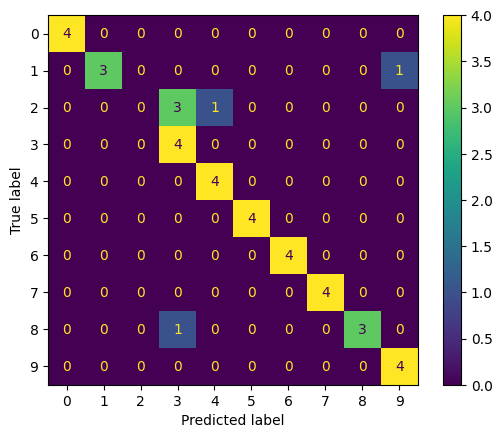

In [11]:
cm = confusion_matrix(y_true=ground_truths, y_pred=preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

### Experiment 3: Speaker-Independent IWR

Select training recordings from one speaker $S_i$ and test recordings from another speaker $S_j$. Compute the Precision, Recall, and F1 metrics, and plot the confusion matrix.

In [12]:
preds = []
ground_truths = []

# train on jackson and test on george
jackson_train = speaker_datasets["jackson"].train
george_test = speaker_datasets["george"].test

for audio in george_test:
    result = recognize(obs=audio["mfccs"], refs=jackson_train)
    pred_digit, pred_speaker = result

    preds.append(pred_digit)
    ground_truths.append(audio["digitLabel"])

# you can use scikit-learn for metric computation
# how are these classification metrics computed?
print("Accuracy: {}".format(accuracy_score(y_true=ground_truths, y_pred=preds)))
print("Precision: {}".format(precision_score(y_true=ground_truths, y_pred=preds, average="macro", zero_division=0)))
print("Recall: {}".format(recall_score(y_true=ground_truths, y_pred=preds, average="macro", zero_division=0)))
print("F1: {}".format(f1_score(y_true=ground_truths, y_pred=preds, average="macro", zero_division=0)))

Accuracy: 0.3
Precision: 0.22857142857142856
Recall: 0.3
F1: 0.2294025974025974


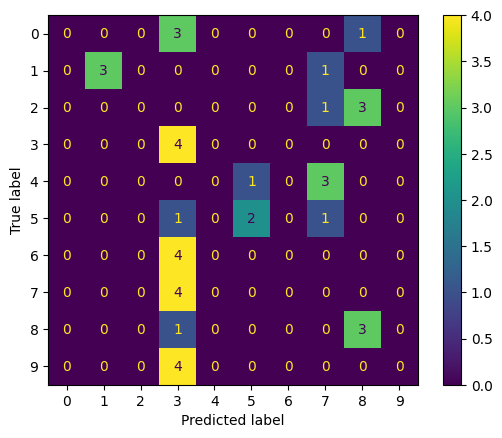

In [13]:
cm = confusion_matrix(y_true=ground_truths, y_pred=preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()